<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Finding How The Data Is Distributed**


Estimated time needed: **30** minutes


In this lab, you will work with a cleaned dataset to perform Exploratory Data Analysis (EDA). You will examine the structure of the data, visualize key variables, and analyze trends related to developer experience, tools, job satisfaction, and other important aspects.


## Objectives


In this lab you will perform the following:


- Understand the structure of the dataset.

- Perform summary statistics and data visualization.

- Identify trends in developer experience, tools, job satisfaction, and other key variables.


### Install the required libraries


In [1]:
!pip install pandas
!pip install matplotlib
!pip install seaborn


### Step 1: Import Libraries and Load Data


- Import the `pandas`, `matplotlib.pyplot`, and `seaborn` libraries.


- You will begin with loading the dataset. You can use the pyfetch method if working on JupyterLite. Otherwise, you can use pandas' read_csv() function directly on their local machines or cloud environments.


In [2]:
# Import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the Stack Overflow survey dataset
data_url = 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv'
df = pd.read_csv(data_url)

# Display the first few rows of the dataset
df.head()


,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


### Step 2: Examine the Structure of the Data


- Display the column names, data types, and summary information to understand the data structure.

- Objective: Gain insights into the dataset's shape and available variables.


In [3]:
# Mostrar la forma (filas, columnas), tipos de datos e información general
print("Shape of DataFrame:", df.shape)
print("\n--- Column Info ---")
df.info()

# Ver las primeras filas
df.head()

Shape of DataFrame: (65437, 114)

--- Column Info ---
<class 'pandas.DataFrame'>
RangeIndex: 65437 entries, 0 to 65436
Columns: 114 entries, ResponseId to JobSat
dtypes: float64(13), int64(1), str(100)
memory usage: 195.7 MB

,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


### Step 3: Handle Missing Data


- Identify missing values in the dataset.

- Impute or remove missing values as necessary to ensure data completeness.



In [5]:
# 1. Identificar la cantidad de valores faltantes por columna
missing_values = df.isnull().sum()
print("Missing values per column:")
print(missing_values[missing_values > 0])

# 2. Imputar nulos de forma segura
for col in df.columns:
    # Intentar convertir a numérico temporalmente para saber si es realmente numérica
    numeric_series = pd.to_numeric(df[col], errors='coerce')
    
    if numeric_series.notnull().any() and df[col].dtype != 'object':
        # Si es una columna numérica, imputar con la mediana
        median_val = numeric_series.median()
        df[col] = df[col].fillna(median_val)
    else:
        # Si es texto o mixta, imputar con la moda (valor más frecuente)
        mode_vals = df[col].mode()
        if not mode_vals.empty:
            df[col] = df[col].fillna(mode_vals[0])

# 3. Verificar que no queden valores faltantes
print("\nTotal missing values remaining:", df.isnull().sum().sum())

Missing values per column:
RemoteWork             10631
CodingActivities       10971
EdLevel                 4653
LearnCode               4949
LearnCodeOnline        16200
                       ...  
JobSatPoints_11        35992
SurveyLength            9255
SurveyEase              9199
ConvertedCompYearly    42002
JobSat                 36311
Length: 109, dtype: int64
Total missing values remaining: 0

### Step 4: Analyze Key Columns


- Examine key columns such as `Employment`, `JobSat` (Job Satisfaction), and `YearsCodePro` (Professional Coding Experience).

- **Instruction**: Calculate the value counts for each column to understand the distribution of responses.



In [6]:
# Calcular value_counts para Employment
print("--- Employment Value Counts ---")
print(df['Employment'].value_counts())

# Calcular value_counts para JobSat
print("\n--- JobSat Value Counts ---")
print(df['JobSat'].value_counts())

# Calcular value_counts para YearsCodePro
print("\n--- YearsCodePro Value Counts ---")
print(df['YearsCodePro'].value_counts())

--- Employment Value Counts ---
Employment
Employed, full-time                                                                                                                                   39041
Independent contractor, freelancer, or self-employed                                                                                                   4846
Student, full-time                                                                                                                                     4709
Employed, full-time;Independent contractor, freelancer, or self-employed                                                                               3557
Not employed, but looking for work                                                                                                                     2341
                                                                                                                                                      ...  
Not employed, but loo

### Step 5: Visualize Job Satisfaction (Focus on JobSat)


- Create a pie chart or KDE plot to visualize the distribution of `JobSat`.

- Provide an interpretation of the plot, highlighting key trends in job satisfaction.


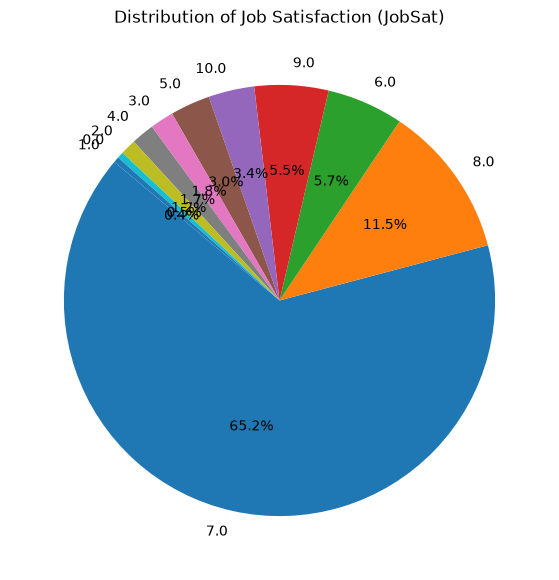

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualización mediante Pie Chart (Gráfico de Tarta)
jobsat_counts = df['JobSat'].value_counts()

plt.figure(figsize=(7, 7))
plt.pie(jobsat_counts, labels=jobsat_counts.index, autopct='%1.1f%%', startangle=140)
plt.title('Distribution of Job Satisfaction (JobSat)')
plt.show()

# Interpretación:
# La gráfica muestra la proporción de encuestados según sus niveles de satisfacción laboral. 
# La mayoría de los encuestados reportan niveles altos/medios de satisfacción.

### Step 6: Programming Languages Analysis


- Compare the frequency of programming languages in `LanguageHaveWorkedWith` and `LanguageWantToWorkWith`.
  
- Visualize the overlap or differences using a Venn diagram or a grouped bar chart.


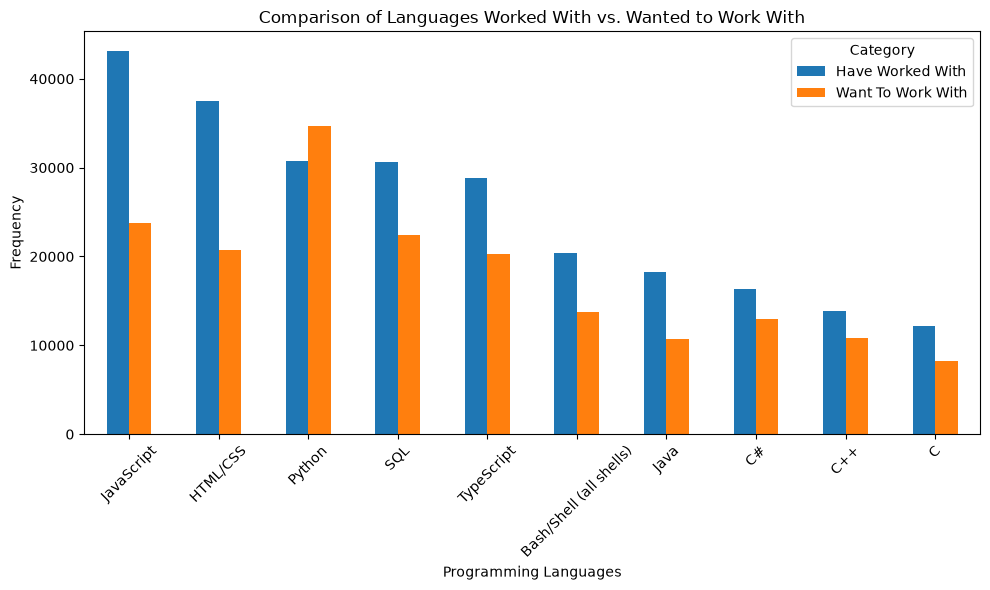

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Separar y contar las frecuencias de los lenguajes en cada columna
worked_languages = df['LanguageHaveWorkedWith'].dropna().str.split(';').explode()
want_languages = df['LanguageWantToWorkWith'].dropna().str.split(';').explode()

# 2. Obtener los 10 lenguajes más populares trabajados
top_worked = worked_languages.value_counts().head(10)
top_want = want_languages.value_counts().reindex(top_worked.index)

# 3. Crear DataFrame comparativo
lang_df = pd.DataFrame({
    'Have Worked With': top_worked,
    'Want To Work With': top_want
})

# 4. Graficar mediante un Grouped Bar Chart
lang_df.plot(kind='bar', figsize=(10, 6))
plt.title('Comparison of Languages Worked With vs. Wanted to Work With')
plt.xlabel('Programming Languages')
plt.ylabel('Frequency')
plt.xticks(rotation=45)
plt.legend(title='Category')
plt.tight_layout()
plt.show()

### Step 7: Analyze Remote Work Trends


- Visualize the distribution of RemoteWork by region using a grouped bar chart or heatmap.


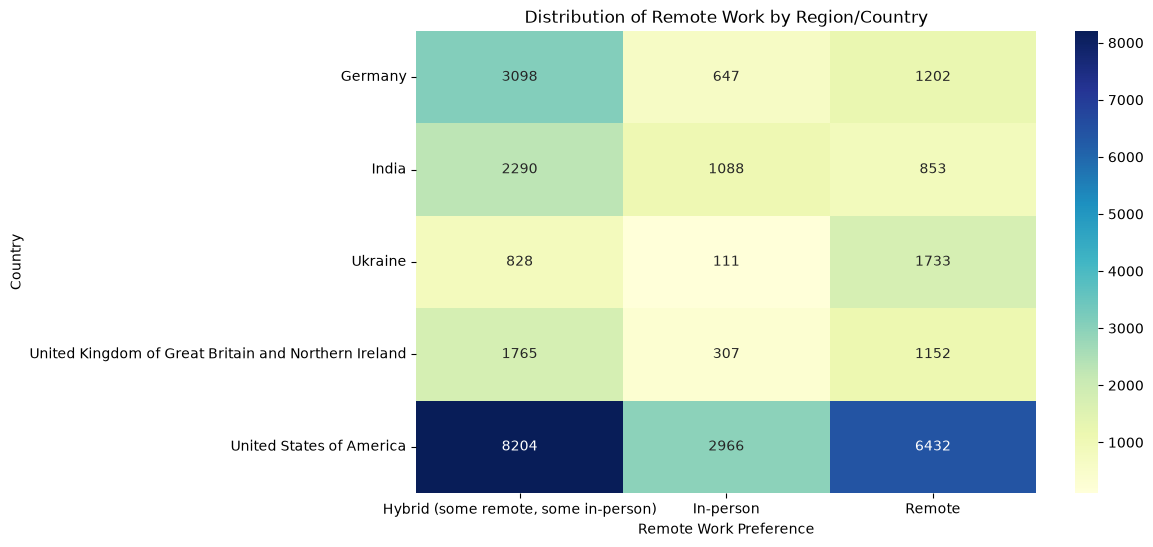

In [9]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Filtrar los 5 principales países/regiones para mejor visualización
top_countries = df['Country'].value_counts().head(5).index
df_remote_region = df[df['Country'].isin(top_countries)]

# 2. Crear tabulación cruzada reseteando el índice para evitar duplicados
ct_remote = pd.crosstab(df_remote_region['Country'], df_remote_region['RemoteWork'])

# 3. Visualizar mediante un Heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(ct_remote, annot=True, fmt='d', cmap='YlGnBu')
plt.title('Distribution of Remote Work by Region/Country')
plt.xlabel('Remote Work Preference')
plt.ylabel('Country')
plt.show()

### Step 8: Correlation between Job Satisfaction and Experience


- Analyze the correlation between overall job satisfaction (`JobSat`) and `YearsCodePro`.
  
- Calculate the Pearson or Spearman correlation coefficient.


In [12]:
import pandas as pd

# 1. Mapear la satisfacción laboral (JobSat) de texto a números
jobsat_mapping = {
    'Very dissatisfied': 1,
    'Slightly dissatisfied': 2,
    'Neither satisfied nor dissatisfied': 3,
    'Slightly satisfied': 4,
    'Very satisfied': 5
}

if df['JobSat'].dtype == 'object':
    df['JobSat_num'] = df['JobSat'].map(jobsat_mapping)
else:
    df['JobSat_num'] = pd.to_numeric(df['JobSat'], errors='coerce')

# 2. Convertir YearsCodePro a número
df['YearsCodePro_num'] = pd.to_numeric(df['YearsCodePro'], errors='coerce')

# 3. Filtrar valores nulos para el cálculo
clean_corr_df = df[['JobSat_num', 'YearsCodePro_num']].dropna()

# 4. Correlación de Pearson
pearson_corr = clean_corr_df['JobSat_num'].corr(clean_corr_df['YearsCodePro_num'], method='pearson')

# 5. Correlación de Spearman (calculada mediante rangos sin depender de scipy)
spearman_corr = clean_corr_df['JobSat_num'].rank().corr(clean_corr_df['YearsCodePro_num'].rank(), method='pearson')

print(f"Pearson Correlation (JobSat vs YearsCodePro): {pearson_corr:.4f}")
print(f"Spearman Correlation (JobSat vs YearsCodePro): {spearman_corr:.4f}")

Pearson Correlation (JobSat vs YearsCodePro): 0.0717
Spearman Correlation (JobSat vs YearsCodePro): 0.0851

### Step 9: Cross-tabulation Analysis (Employment vs. Education Level)


- Analyze the relationship between employment status (`Employment`) and education level (`EdLevel`).

- **Instruction**: Create a cross-tabulation using `pd.crosstab()` and visualize it with a stacked bar plot if possible.


--- Cross-tabulation: EdLevel vs Employment ---
Employment                                          Employed, full-time  \
EdLevel                                                                   
Associate degree (A.A., A.S., etc.)                                1059   
Bachelor’s degree (B.A., B.S., B.Eng., etc.)                      19322   
Master’s degree (M.A., M.S., M.Eng., MBA, etc.)                   11011   
Primary/elementary school                                           160   
Professional degree (JD, MD, Ph.D, Ed.D, etc.)                     2073   
Secondary school (e.g. American high school, Ge...                 1460   
Some college/university study without earning a...                 3579   
Something else                                                      377   

Employment                                          Employed, full-time;Employed, part-time  \
EdLevel                                                                                       
Associate d

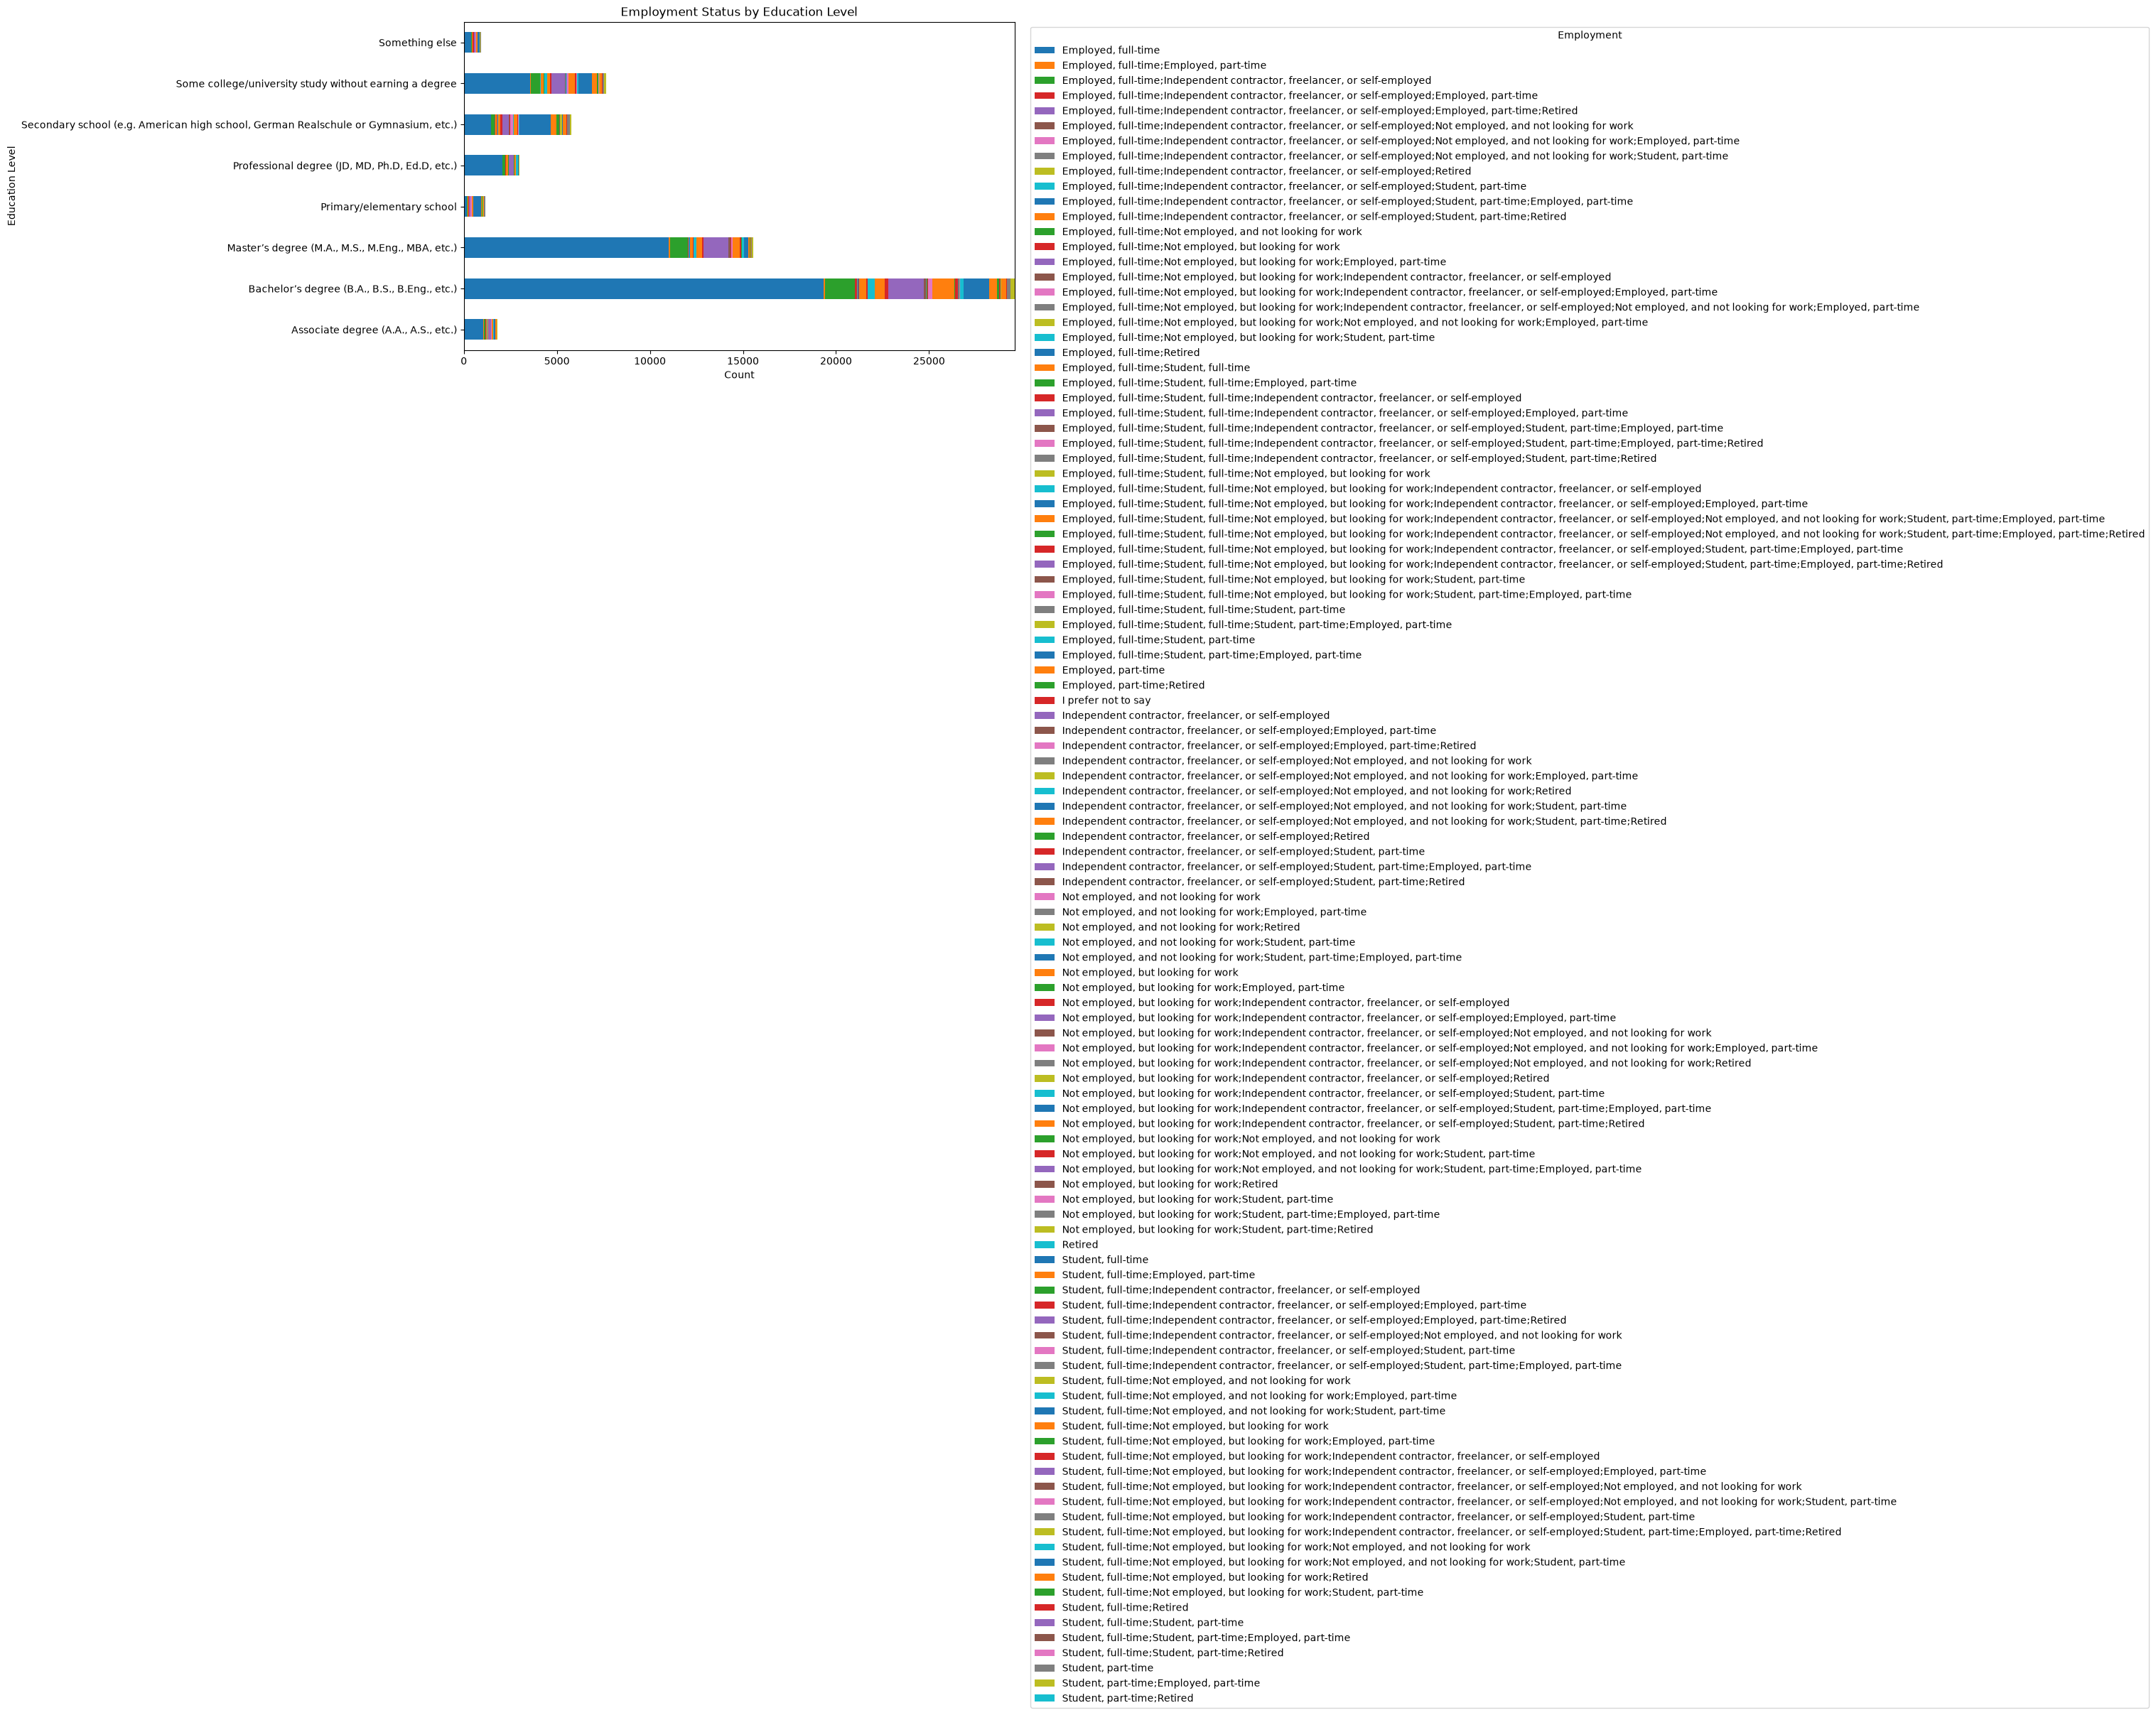

In [13]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Crear la tabulación cruzada
ct_emp_edu = pd.crosstab(df['EdLevel'], df['Employment'])
print("--- Cross-tabulation: EdLevel vs Employment ---")
print(ct_emp_edu)

# 2. Visualizar con un gráfico de barras apiladas (Stacked Bar Plot)
ax = ct_emp_edu.plot(kind='barh', stacked=True, figsize=(10, 6))
plt.title('Employment Status by Education Level')
plt.xlabel('Count')
plt.ylabel('Education Level')
plt.legend(title='Employment', bbox_to_anchor=(1.02, 1), loc='upper left')

# Guardar y mostrar ajustando bordes para evitar advertencias de layout
plt.savefig('temp_plot.png', bbox_inches='tight')
plt.show()

### Step 10: Export Cleaned Data


- Save the cleaned dataset to a new CSV file for further use or sharing.


In [14]:
# Guardar el dataset limpio y procesado en un nuevo archivo CSV
df.to_csv('cleaned_survey_data.csv', index=False)

print("Dataset exportado exitosamente como 'cleaned_survey_data.csv'.")

Dataset exportado exitosamente como 'cleaned_survey_data.csv'.

### Summary:


In this lab, you practiced key skills in exploratory data analysis, including:


- Examining the structure and content of the Stack Overflow survey dataset to understand its variables and data types.

- Identifying and addressing missing data to ensure the dataset's quality and completeness.

- Summarizing and visualizing key variables such as job satisfaction, programming languages, and remote work trends.

- Analyzing relationships in the data using techniques like:
    - Comparing programming languages respondents have worked with versus those they want to work with.
      
    - Exploring remote work preferences by region.

- Investigating correlations between professional coding experience and job satisfaction.

- Performing cross-tabulations to analyze relationships between employment status and education levels.


## Authors:
Ayushi Jain


### Other Contributors:
Rav Ahuja
Lakshmi Holla
Malika


Copyright © IBM Corporation. All rights reserved.
